<a href="https://colab.research.google.com/github/carmen74goma-pixel/-McCullock-Pitts/blob/main/Modelos_Estoc%C3%A1sticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cetes a 28 días con curva de plazos para los valores de los
Cetes de un año entre el 2003 y el 2026

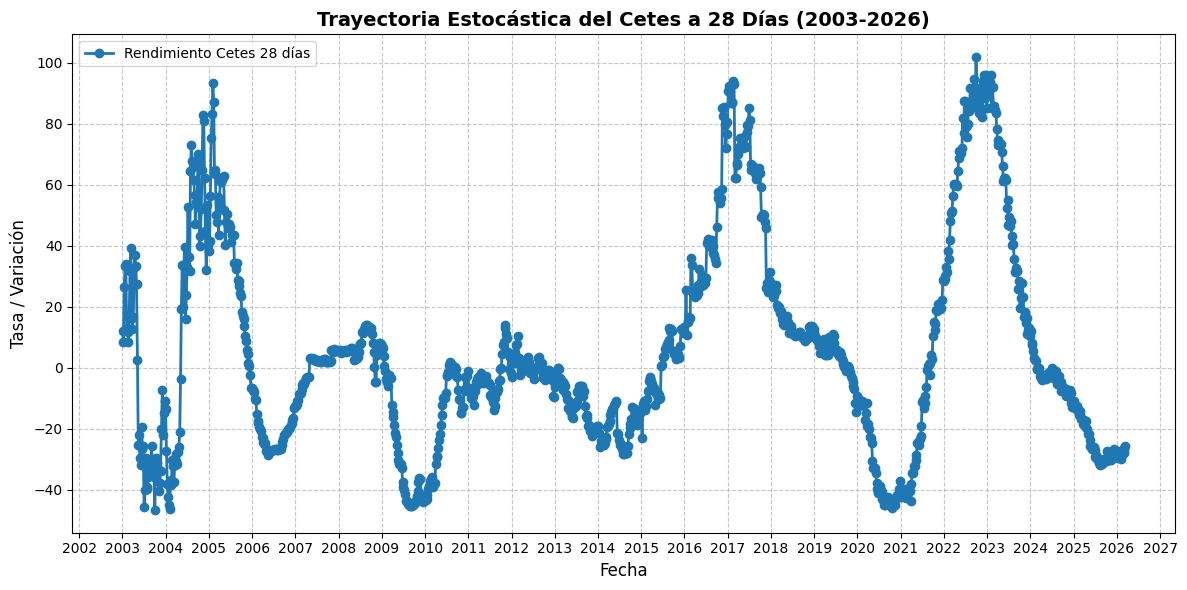

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import matplotlib.dates as mdates

# 1. Leer los datos transponiendo las filas de interés
# Nota: Según el archivo subido, los encabezados de fechas inician en la fila 11
# y los rendimientos en la fila 13. (Índices 10 y 12 en Python)
# Se cambia la codificación a 'latin-1' para resolver el UnicodeDecodeError
with open("/content/Consulta_20260311-195908977.csv", "r", encoding="latin-1") as f:
    reader = csv.reader(f)
    rows = list(reader)

fechas = rows[10][3:]    # Omitimos las tres primeras columnas de metadatos
valores = rows[12][3:]

# 2. Estructurar en Pandas y limpiar los tipos de datos
df = pd.DataFrame({'Fecha': fechas, 'Rendimiento': valores})
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y', errors='coerce')
df['Rendimiento'] = pd.to_numeric(df['Rendimiento'], errors='coerce')

# Ordenar cronológicamente y limpiar valores nulos
df = df.dropna().sort_values('Fecha')

# 3. Filtrar para un rango de años (Ejemplo: 2023 a 2026)
start_year = 2003
end_year = 2026
df_filtered = df[(df['Fecha'].dt.year >= start_year) & (df['Fecha'].dt.year <= end_year)]

# (Opcional) Exportar a un CSV limpio para modelado
df_filtered.to_csv(f'Cetes_28_dias_{start_year}_{end_year}.csv', index=False)

# 4. Graficar la trayectoria estocástica
fig, ax = plt.subplots(figsize=(12, 6))

# Trazar el camino de la serie de tiempo (sample path)
ax.plot(df_filtered['Fecha'], df_filtered['Rendimiento'], marker='o', linestyle='-',
        color='#1f77b4', linewidth=2, label='Rendimiento Cetes 28 días')

# Formatear el eje X para que muestre los meses adecuadamente
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Etiquetas y diseño
plt.title(f'Trayectoria Estocástica del Cetes a 28 Días ({start_year}-{end_year})', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Tasa / Variación', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Guardar o mostrar gráfico
plt.savefig(f'stochastic_cetes_{start_year}_{end_year}.png')
# plt.show() # Usar plt.show() si estás corriendo el código localmente